# Group Project — Data Engineering & EDA Pipeline
### Focused question: How does AI adoption rate compare with productivity rate?
Dataset: AI Adoption in Companies (`ai_company_adoption.csv`, from `archive.zip`)

**Narrowing note (per lecturer feedback):** the earlier draft explored too many variables at
once. This version keeps the same ETL/EDA pipeline structure used in the Week 2–3 lab, but the
analysis (Task 3–4) is narrowed to a **single comparison**:

- `ai_adoption_rate` — the % of a company's operations/processes using AI (the variable of interest)
- `productivity_change_percent` — the % change in productivity reported for that company-quarter (the outcome we compare it against)

**Dataset structure (Task 2 documentation):** 150,000 rows = quarterly survey responses from
10,000 companies (~16 quarters each, 2023–2026), 43 columns in total. We keep the full raw
dataset for inspection/data-quality purposes, but every cleaning and exploration step from
Step 6 onward works only with the two focus columns (plus lightweight identifiers for context).

> Why this comparison matters: it directly tests the project's core question — whether higher
> AI adoption is associated with higher reported productivity gains, which is the central
> business case for AI investment that this dataset is meant to evaluate.

In [1]:
import pandas as pd
import zipfile
import os

# Load the approved dataset (extract from archive.zip if the CSV isn't already alongside this notebook)
CSV_NAME = "ai_company_adoption.csv"
ZIP_NAME = "archive.zip"

if not os.path.exists(CSV_NAME) and os.path.exists(ZIP_NAME):
    with zipfile.ZipFile(ZIP_NAME) as z:
        z.extractall(".")

df = pd.read_csv(CSV_NAME)

print("Raw shape:", df.shape)
print(df.head())

Raw shape: (150000, 43)
   response_id  company_id  survey_year quarter country  region   industry  \
0            1  COMP-00001         2023      Q1   Italy  Europe  Education   
1            2  COMP-00001         2023      Q2   Italy  Europe  Education   
2            3  COMP-00001         2023      Q3   Italy  Europe  Education   
3            4  COMP-00001         2023      Q4   Italy  Europe  Education   
4            5  COMP-00001         2024      Q1   Italy  Europe  Education   

  company_size  num_employees  annual_revenue_usd_millions  ...  \
0      Startup             57                        48.31  ...   
1      Startup             57                        48.31  ...   
2      Startup             57                        48.31  ...   
3      Startup             57                        48.31  ...   
4      Startup             57                        48.31  ...   

   productivity_change_percent  jobs_displaced jobs_created  \
0                         2.65           

## Step 1 — Why this data, and why it matters
The dataset is a repeated (quarterly) survey of companies reporting how far they have rolled out
AI (`ai_adoption_rate`) alongside business outcomes, including `productivity_change_percent`.
It was collected to let researchers/organisations evaluate whether AI adoption is actually
paying off in measurable productivity terms — which is exactly the question this notebook narrows
down to.

## Step 2 (adapted) — Load and type the dataset
Unlike the Arrhythmia lab file, `ai_company_adoption.csv` already has a header row, so no manual
column naming is needed. We only need `quarter` typed as a category (used later purely as a
lightweight time label, not as an extra analysis variable).

In [2]:
df["quarter"] = df["quarter"].astype("category")

print(df.dtypes.value_counts())
print("\nFocus columns present:",
      "ai_adoption_rate" in df.columns and "productivity_change_percent" in df.columns)

float64     15
int64       14
str         13
category     1
Name: count, dtype: int64

Focus columns present: True


## Step 3 (adapted) — Protect the raw data and describe structure
Same pattern as the lab: keep an untouched `df_original`, and never edit it directly. All
cleaning happens on copies via a `clean_data()` function.

In [3]:
df_original = df.copy(deep=True)

print("Records:", df_original.shape[0])
print("Columns:", df_original.shape[1])

print("\nFirst observation — the two focus columns:")
print(df_original[["ai_adoption_rate", "productivity_change_percent"]].describe())

Records: 150000
Columns: 43

First observation — the two focus columns:
       ai_adoption_rate  productivity_change_percent
count     150000.000000                150000.000000
mean          36.414726                     9.266996
std           14.544096                     5.637067
min            0.000000                     0.000000
25%           26.430000                     5.070000
50%           36.320000                     9.060000
75%           46.200000                    13.120000
max          100.000000                    34.360000


## Step 4 (adapted) — Inspect data quality before cleaning
Check missingness, duplicates, and ranges — but only for what the narrowed comparison needs:
`ai_adoption_rate` and `productivity_change_percent`.

In [4]:
focus_cols = ["ai_adoption_rate", "productivity_change_percent"]

# Missing values, evidenced explicitly (per feedback: "provide evidence, equally no missing data")
missing_focus = df_original[focus_cols].isna().sum()
print("Missing values in the focus columns:")
print(missing_focus)
if missing_focus.sum() == 0:
    print("-> Confirmed: no missing data in either focus column.")

# Duplicate rows
print("\nNumber of fully duplicate rows:", df_original.duplicated().sum())
print("Number of duplicate response_id values:", df_original["response_id"].duplicated().sum())

# Ranges / plausibility check
print("\nMinimum and maximum values:")
print(df_original[focus_cols].agg(["min", "max"]))

Missing values in the focus columns:
ai_adoption_rate               0
productivity_change_percent    0
dtype: int64
-> Confirmed: no missing data in either focus column.



Number of fully duplicate rows: 0
Number of duplicate response_id values: 0

Minimum and maximum values:
     ai_adoption_rate  productivity_change_percent
min               0.0                         0.00
max             100.0                        34.36


## Step 5 — Define, apply and verify the cleaning function
Same shape as the lab's `clean_data()`: work on a deep copy, remove any record that is invalid
for the two focus columns, deduplicate, and keep only what the narrowed comparison needs
(the two focus columns, plus `company_id`/`survey_year`/`quarter` as lightweight identifiers for
traceability — not additional analysis variables).

In [5]:
def clean_data(data):
    clean = data.copy(deep=True)

    # Keep only rows with valid values for the two focus columns
    invalid_record = (
        clean["ai_adoption_rate"].isna()
        | clean["productivity_change_percent"].isna()
        | (clean["ai_adoption_rate"] < 0)
        | (clean["ai_adoption_rate"] > 100)
    )
    print("Invalid/missing records removed:", invalid_record.sum())

    clean = clean.loc[~invalid_record].copy()
    clean = clean.drop_duplicates()

    # Narrow the working frame down to the single comparison, plus lightweight identifiers
    keep_cols = ["company_id", "survey_year", "quarter",
                 "ai_adoption_rate", "productivity_change_percent"]
    clean = clean[keep_cols].reset_index(drop=True)
    return clean

df_etl_clean = clean_data(df_original)

print("Original shape:", df_original.shape)
print("Cleaned shape:", df_etl_clean.shape)
print("Rows removed:", len(df_original) - len(df_etl_clean))
print("Duplicate rows remaining:", df_etl_clean.duplicated().sum())

Invalid/missing records removed: 0


Original shape: (150000, 43)
Cleaned shape: (150000, 5)
Rows removed: 0
Duplicate rows remaining: 0


## Step 6 — Demonstrate ETL and ELT
Identical pattern to the lab, just against our two-column comparison table.

In [6]:
import sqlite3

# ETL: transform first, then load
with sqlite3.connect("etl.db") as conn:
    df_etl_clean.to_sql("clean", conn, if_exists="replace", index=False)

# ELT: load raw first, then transform
with sqlite3.connect("elt.db") as conn:
    df_original.to_sql("raw", conn, if_exists="replace", index=False)

    df_elt_raw = pd.read_sql("SELECT * FROM raw", conn)
    df_elt_clean = clean_data(df_elt_raw)
    df_elt_clean.to_sql("clean", conn, if_exists="replace", index=False)

print("ETL clean shape:", df_etl_clean.shape)
print("ELT raw shape:", df_elt_raw.shape)
print("ELT clean shape:", df_elt_clean.shape)

Invalid/missing records removed: 0


ETL clean shape: (150000, 5)
ELT raw shape: (150000, 43)
ELT clean shape: (150000, 5)


In [7]:
with sqlite3.connect("etl.db") as conn:
    print("Tables in etl.db:")
    print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))

with sqlite3.connect("elt.db") as conn:
    print("\nTables in elt.db:")
    print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))

Tables in etl.db:
    name
0  clean

Tables in elt.db:
    name
0    raw
1  clean


## Part A — Series vs DataFrame, and loop vs vectorised execution
Same demonstration as the lab, using `ai_adoption_rate` in place of `weight / height`.

In [8]:
# Series versus DataFrame
print(df_etl_clean["ai_adoption_rate"].mean())
print(df_etl_clean[["ai_adoption_rate", "productivity_change_percent"]].mean())

import time
# Slow method: loop, converting adoption rate from % to a 0-1 fraction
start = time.time()
slow_result = []
for i in range(len(df_etl_clean)):
    slow_result.append(df_etl_clean["ai_adoption_rate"].iloc[i] / 100)
slow_time = time.time() - start

# Fast method: vectorised calculation
start = time.time()
fast_result = df_etl_clean["ai_adoption_rate"] / 100
fast_time = time.time() - start

print("Slow result:", slow_result[:5])
print("Fast result:", fast_result.head().tolist())
print("\nSlow time:", slow_time)
print("Fast time:", fast_time)
print("Fast method is", slow_time / fast_time, "times faster")

36.41472566666666
ai_adoption_rate               36.414726
productivity_change_percent     9.266996
dtype: float64


Slow result: [np.float64(0.3057), np.float64(0.2725), np.float64(0.3154), np.float64(0.11019999999999999), np.float64(0.33390000000000003)]
Fast result: [0.3057, 0.2725, 0.3154, 0.11019999999999999, 0.33390000000000003]

Slow time: 2.0531697273254395
Fast time: 0.0005791187286376953
Fast method is 3545.3347056401813 times faster


## Part B — Exploration of the single comparison
### 1. Descriptive statistics for both variables

In [9]:
print(df_etl_clean[focus_cols].describe())

skew_results = df_etl_clean[focus_cols].skew().round(2)
print("\nSkew:")
print(skew_results)

       ai_adoption_rate  productivity_change_percent
count     150000.000000                150000.000000
mean          36.414726                     9.266996
std           14.544096                     5.637067
min            0.000000                     0.000000
25%           26.430000                     5.070000
50%           36.320000                     9.060000
75%           46.200000                    13.120000
max          100.000000                    34.360000

Skew:
ai_adoption_rate               0.06
productivity_change_percent    0.30
dtype: float64


### 2. Histograms — distribution of each variable
A histogram is the right chart here because both variables are continuous and we want to see
their overall shape (skew, spread) before comparing them to each other.

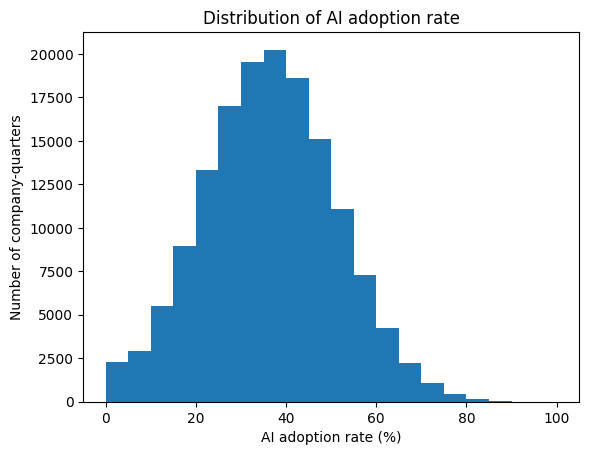

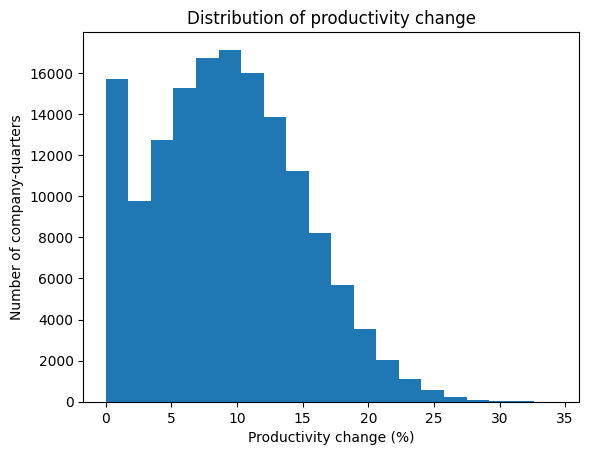

In [10]:
import matplotlib.pyplot as plt

plt.hist(df_etl_clean["ai_adoption_rate"].dropna(), bins=20)
plt.xlabel("AI adoption rate (%)")
plt.ylabel("Number of company-quarters")
plt.title("Distribution of AI adoption rate")
plt.show()

plt.hist(df_etl_clean["productivity_change_percent"].dropna(), bins=20)
plt.xlabel("Productivity change (%)")
plt.ylabel("Number of company-quarters")
plt.title("Distribution of productivity change")
plt.show()

### 3. Outlier check — boxplots and IQR flags
A boxplot is the right chart for spotting outliers at a glance in a single continuous variable.

/tmp/ipykernel_544/3529923229.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(df_etl_clean["ai_adoption_rate"].dropna(), labels=["AI adoption rate"])
/tmp/ipykernel_544/3529923229.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(df_etl_clean["productivity_change_percent"].dropna(), labels=["Productivity change"])


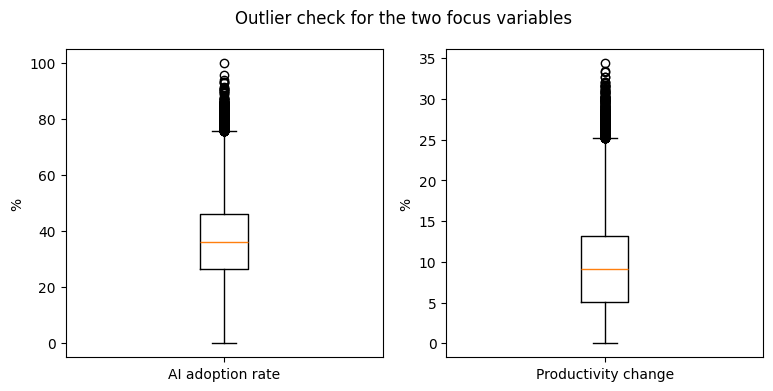

AI adoption rate outliers (IQR rule): 504 of 150000
Productivity change outliers (IQR rule): 529 of 150000


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].boxplot(df_etl_clean["ai_adoption_rate"].dropna(), tick_labels=["AI adoption rate"])
axes[0].set_ylabel("%")
axes[1].boxplot(df_etl_clean["productivity_change_percent"].dropna(), tick_labels=["Productivity change"])
axes[1].set_ylabel("%")
plt.suptitle("Outlier check for the two focus variables")
plt.show()

def iqr_flag(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

adoption_outliers = iqr_flag(df_etl_clean["ai_adoption_rate"])
productivity_outliers = iqr_flag(df_etl_clean["productivity_change_percent"])

print("AI adoption rate outliers (IQR rule):", adoption_outliers.sum(), "of", len(df_etl_clean))
print("Productivity change outliers (IQR rule):", productivity_outliers.sum(), "of", len(df_etl_clean))

### 4. Scatter plot — the core comparison
This is the chart that directly answers the research question: does a higher AI adoption rate
line up with a higher productivity change? A scatter plot is the right choice for showing the
relationship between two continuous variables, with a fitted trend line to make the direction of
any relationship visible.

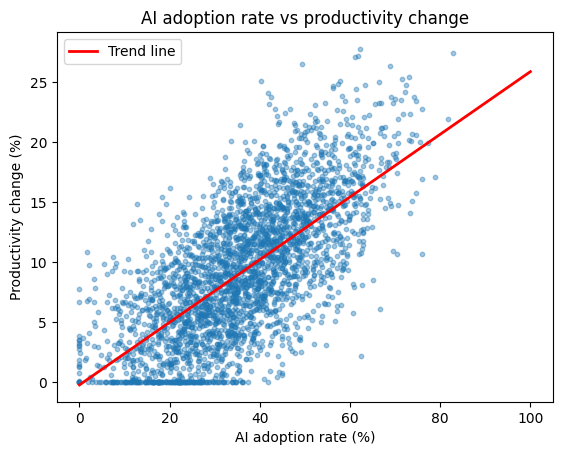

Fitted line: productivity_change_percent = 0.2616 * ai_adoption_rate + -0.26


In [12]:
import numpy as np

x = df_etl_clean["ai_adoption_rate"]
y = df_etl_clean["productivity_change_percent"]

# Sample for plotting only (150,000 points is too dense to read); all stats below use the full data
sample = df_etl_clean.sample(n=3000, random_state=42)

plt.scatter(sample["ai_adoption_rate"], sample["productivity_change_percent"], alpha=0.4, s=10)

# Fitted trend line (least-squares, on the full cleaned dataset)
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, slope * x_line + intercept, color="red", linewidth=2, label="Trend line")

plt.xlabel("AI adoption rate (%)")
plt.ylabel("Productivity change (%)")
plt.title("AI adoption rate vs productivity change")
plt.legend()
plt.show()

print(f"Fitted line: productivity_change_percent = {slope:.4f} * ai_adoption_rate + {intercept:.2f}")

### 5. Grouped view — productivity by adoption band
To make the same relationship easier to read, we bucket `ai_adoption_rate` into Low/Medium/High
bands (a derived view of the *same* variable, not a new one) and compare mean productivity change
across the bands with a bar chart.

adoption_band
Low (0-33%)         5.622641
Medium (33-67%)    11.632306
High (67-100%)     18.967312
Name: productivity_change_percent, dtype: float64


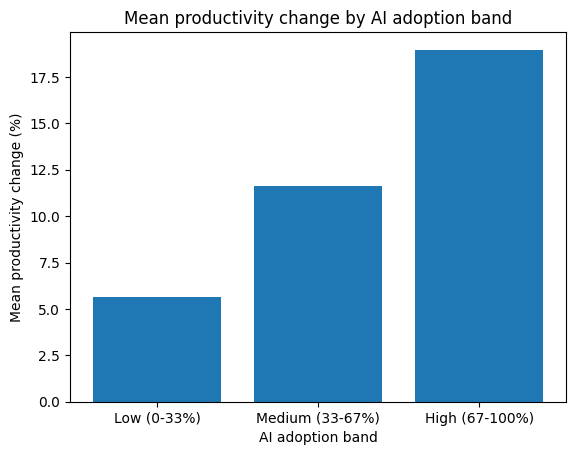

In [13]:
df_etl_clean["adoption_band"] = pd.cut(
    df_etl_clean["ai_adoption_rate"],
    bins=[-0.01, 33.3, 66.6, 100],
    labels=["Low (0-33%)", "Medium (33-67%)", "High (67-100%)"],
)

band_means = df_etl_clean.groupby("adoption_band", observed=True)["productivity_change_percent"].mean()
print(band_means)

plt.bar(band_means.index.astype(str), band_means.values)
plt.xlabel("AI adoption band")
plt.ylabel("Mean productivity change (%)")
plt.title("Mean productivity change by AI adoption band")
plt.show()

### 6. Statistical hypothesis test
We test the relationship directly with a **Pearson correlation test**: is the correlation
between `ai_adoption_rate` and `productivity_change_percent` statistically significant?

- H0: there is no linear correlation between AI adoption rate and productivity change (r = 0)
- H1: there is a linear correlation between the two (r ≠ 0)

In [14]:
from scipy import stats

r, p = stats.pearsonr(df_etl_clean["ai_adoption_rate"], df_etl_clean["productivity_change_percent"])

print(f"Pearson r = {r:.4f}, p = {p:.6f}")

if p < 0.05:
    print("Reject H0: AI adoption rate and productivity change are significantly correlated.")
else:
    print("Fail to reject H0: no significant linear correlation was detected.")

# Supporting test: one-way ANOVA across the three adoption bands
low = df_etl_clean.loc[df_etl_clean["adoption_band"] == "Low (0-33%)", "productivity_change_percent"]
med = df_etl_clean.loc[df_etl_clean["adoption_band"] == "Medium (33-67%)", "productivity_change_percent"]
high = df_etl_clean.loc[df_etl_clean["adoption_band"] == "High (67-100%)", "productivity_change_percent"]

f_stat, p_anova = stats.f_oneway(low, med, high)
print(f"\nOne-way ANOVA across adoption bands: F = {f_stat:.2f}, p = {p_anova:.6f}")

if p_anova < 0.05:
    print("Reject H0: mean productivity change differs significantly across adoption bands.")
else:
    print("Fail to reject H0: no significant difference in mean productivity change was detected.")

Pearson r = 0.6750, p = 0.000000
Reject H0: AI adoption rate and productivity change are significantly correlated.

One-way ANOVA across adoption bands: F = 37481.63, p = 0.000000
Reject H0: mean productivity change differs significantly across adoption bands.
